# Chapter 7: Medical Symptom Triage

A patient contacts a healthcare service. They describe their symptoms. Someone -- or something -- has to decide how urgently they need to be seen.

Traditional triage uses structured protocols: numerical scores, decision trees, trained clinicians working through standardised questions. These work well but require skilled human time. At scale -- a busy NHS 111 service, a telehealth platform handling thousands of daily contacts -- the bottleneck is always clinical capacity.

This chapter uses Jev to assign each patient presentation to one of four care pathways: Emergency, Urgent Care, Routine or Self-Care. One `Choice` call per presentation, patient symptoms and context in the state, calibrated confidence alongside the decision.

The goal is not to replace clinical triage. It is to illustrate where confidence-scored structured decisions can help: routing clear cases quickly and flagging uncertain ones for human review.

---

## ⚠ Critical disclaimer

**This chapter is for illustrative and educational purposes only.**

The presentations, decisions and confidence scores in this notebook are fictional. Jev is not a medical device, has not been clinically validated and must not be used to make or influence real healthcare decisions.

**If you or someone else is experiencing a medical emergency, call the emergency services immediately.**

Any real application of AI in clinical triage requires regulatory approval, clinical validation, human oversight and clear accountability for every decision. Nothing in this chapter should be interpreted as guidance for real-world medical use.

---

## Prerequisites

```shell
export TYPESAFE_API_KEY="your-typesafe-key"
```


## 1. Install dependencies

In [1]:
%pip install pandas==2.2.3 \
             plotly==6.1.2 \
             typesafe-sdk==0.7.2 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration

In [2]:
import os
import pandas as pd
import plotly.graph_objects as go
import time

from typesafe_sdk import Choice, TypeSafeClient

In [3]:
TYPESAFE_API_KEY = os.environ["TYPESAFE_API_KEY"]
print("Configuration set.")

Configuration set.


## 3. Care pathways

Four pathways representing the standard triage levels used in many healthcare systems.

In [4]:
CARE_PATHWAYS = {
    "Emergency": (
        "Potentially life-threatening condition. Patient should call emergency "
        "services or go to A&E immediately. Do not wait."
    ),
    "Urgent Care": (
        "Condition requires clinical assessment within a few hours. Patient "
        "should contact an urgent care centre, out-of-hours GP or similar "
        "same-day service."
    ),
    "Routine": (
        "Condition warrants clinical review but is not urgent. Patient should "
        "book a standard GP appointment within the next few days."
    ),
    "Self-Care": (
        "Condition is minor and can be safely managed at home with rest, "
        "over-the-counter remedies and standard self-care advice."
    ),
}

print("Pathways:", list(CARE_PATHWAYS.keys()))

Pathways: ['Emergency', 'Urgent Care', 'Routine', 'Self-Care']


## 4. Generate synthetic presentations

Twenty fictional patient presentations across four bands. Each carries the reported symptoms, patient age, relevant medical history and how long symptoms have been present.

In [5]:
PRESENTATIONS = [

    # Clear emergency (5)
    {
        "id": "P001",
        "age": 58,
        "sex": "Male",
        "medical_history": "Hypertension, high cholesterol",
        "symptoms": (
            "Crushing chest pain radiating to the left arm, started 20 minutes ago. "
            "Sweating profusely. Feels sick. Slight breathlessness."
        ),
        "duration": "20 minutes",
        "band": "clear_emergency",
    },
    {
        "id": "P002",
        "age": 67,
        "sex": "Female",
        "medical_history": "Type 2 diabetes",
        "symptoms": (
            "Sudden severe headache described as the worst of her life. "
            "Neck stiffness. Sensitivity to light. No fever."
        ),
        "duration": "45 minutes",
        "band": "clear_emergency",
    },
    {
        "id": "P003",
        "age": 34,
        "sex": "Male",
        "medical_history": "No significant history",
        "symptoms": (
            "Facial drooping on the right side. Arm weakness on the right. "
            "Speech is slurred. Symptoms came on suddenly about 30 minutes ago."
        ),
        "duration": "30 minutes",
        "band": "clear_emergency",
    },
    {
        "id": "P004",
        "age": 22,
        "sex": "Female",
        "medical_history": "Known peanut allergy",
        "symptoms": (
            "Ate something at a restaurant 15 minutes ago. Now has throat swelling, "
            "hives across the chest and difficulty breathing. Has an EpiPen but "
            "hasn't used it yet."
        ),
        "duration": "15 minutes",
        "band": "clear_emergency",
    },
    {
        "id": "P005",
        "age": 45,
        "sex": "Male",
        "medical_history": "No significant history",
        "symptoms": (
            "Coughing up blood -- about a teaspoon. Has had a cough for 3 weeks "
            "but this is the first time there has been blood. No chest pain. "
            "No fever. Smoker."
        ),
        "duration": "3 weeks (blood: this morning)",
        "band": "clear_emergency",
    },

    # Clear self-care (5)
    {
        "id": "P006",
        "age": 28,
        "sex": "Female",
        "medical_history": "No significant history",
        "symptoms": (
            "Runny nose, mild sore throat, sneezing. Feels tired. "
            "No fever. Symptoms started yesterday."
        ),
        "duration": "1 day",
        "band": "clear_self_care",
    },
    {
        "id": "P007",
        "age": 35,
        "sex": "Male",
        "medical_history": "No significant history",
        "symptoms": (
            "Mild tension headache, rated 3/10. Has had similar headaches before. "
            "No nausea, no visual disturbance, no neck stiffness. "
            "Started after a long day at work staring at a screen."
        ),
        "duration": "3 hours",
        "band": "clear_self_care",
    },
    {
        "id": "P008",
        "age": 19,
        "sex": "Female",
        "medical_history": "No significant history",
        "symptoms": (
            "Small cut on the palm of the hand from a kitchen knife. "
            "Bleeding has stopped. About 1cm long, not deep. "
            "Tetanus vaccination up to date."
        ),
        "duration": "30 minutes",
        "band": "clear_self_care",
    },
    {
        "id": "P009",
        "age": 42,
        "sex": "Male",
        "medical_history": "No significant history",
        "symptoms": (
            "Mild lower back pain after moving furniture yesterday. "
            "No leg pain, no numbness, no bladder or bowel changes. "
            "Rates pain 4/10. Has had similar episodes before that resolved."
        ),
        "duration": "1 day",
        "band": "clear_self_care",
    },
    {
        "id": "P010",
        "age": 31,
        "sex": "Female",
        "medical_history": "No significant history",
        "symptoms": (
            "Mild diarrhoea and stomach cramps. Started last night, probably "
            "after eating out. No blood in stool. No fever. Able to keep fluids "
            "down. Feels better this morning."
        ),
        "duration": "12 hours, improving",
        "band": "clear_self_care",
    },

    # Ambiguous (5)
    {
        "id": "P011",
        "age": 44,
        "sex": "Female",
        "medical_history": "No significant history",
        "symptoms": (
            "Persistent headache for 5 days, not responding to paracetamol. "
            "No nausea. No visual changes. No neck stiffness. "
            "Rates pain 5/10. Has been under a lot of stress at work."
        ),
        "duration": "5 days",
        "band": "ambiguous",
    },
    {
        "id": "P012",
        "age": 52,
        "sex": "Male",
        "medical_history": "No significant history",
        "symptoms": (
            "Chest tightness when climbing stairs, started about a week ago. "
            "No pain at rest. No shortness of breath at rest. "
            "Slightly overweight. Smokes 10 cigarettes a day."
        ),
        "duration": "1 week",
        "band": "ambiguous",
    },
    {
        "id": "P013",
        "age": 38,
        "sex": "Female",
        "medical_history": "No significant history",
        "symptoms": (
            "Abdominal pain, right side, rated 6/10. Started 2 days ago. "
            "No nausea or vomiting. No fever. Not worse after eating. "
            "Bowel habits normal."
        ),
        "duration": "2 days",
        "band": "ambiguous",
    },
    {
        "id": "P014",
        "age": 60,
        "sex": "Male",
        "medical_history": "Type 2 diabetes, controlled",
        "symptoms": (
            "Increased thirst and urination for the past week. Feels more tired "
            "than usual. No blurred vision. Blood sugar readings at home have "
            "been higher than normal but not critically elevated."
        ),
        "duration": "1 week",
        "band": "ambiguous",
    },
    {
        "id": "P015",
        "age": 29,
        "sex": "Female",
        "medical_history": "No significant history",
        "symptoms": (
            "Palpitations -- heart feels like it is racing or skipping beats. "
            "Happens for a few seconds at a time, several times today. "
            "No chest pain. No dizziness. No shortness of breath. "
            "Has had two coffees today."
        ),
        "duration": "Today (intermittent)",
        "band": "ambiguous",
    },

    # Edge cases (5)
    {
        "id": "P016",
        "age": 82,
        "sex": "Female",
        "medical_history": "Osteoporosis, on blood thinners",
        "symptoms": (
            "Fell in the garden about an hour ago. No loss of consciousness. "
            "Bruising to the hip and right arm. Able to bear weight but painful. "
            "No head injury. Lives alone."
        ),
        "duration": "1 hour post-fall",
        "band": "edge",
    },
    {
        "id": "P017",
        "age": 7,
        "sex": "Male",
        "medical_history": "No significant history",
        "symptoms": (
            "Fever of 39.2C for 24 hours. Mild sore throat. Eating and drinking "
            "normally. Active and alert. No rash. No difficulty breathing. "
            "No neck stiffness."
        ),
        "duration": "24 hours",
        "band": "edge",
    },
    {
        "id": "P018",
        "age": 31,
        "sex": "Male",
        "medical_history": "Asthma, mild and well-controlled",
        "symptoms": (
            "Mild wheeze and slight shortness of breath. Has used his reliever "
            "inhaler twice today and felt better each time. No cyanosis. "
            "Peak flow 75% of personal best. Currently feels okay."
        ),
        "duration": "Today",
        "band": "edge",
    },
    {
        "id": "P019",
        "age": 25,
        "sex": "Female",
        "medical_history": "History of anxiety disorder",
        "symptoms": (
            "Racing heart, shortness of breath, tingling in hands and feet, "
            "feeling of dread. Symptoms came on suddenly 20 minutes ago during "
            "a stressful meeting. Has had similar episodes before that were "
            "diagnosed as panic attacks."
        ),
        "duration": "20 minutes",
        "band": "edge",
    },
    {
        "id": "P020",
        "age": 55,
        "sex": "Male",
        "medical_history": "Hypertension, on medication",
        "symptoms": (
            "Noticed vision is slightly blurry in the right eye this morning. "
            "No pain. No headache. No other neurological symptoms. "
            "Blood pressure check at home: 158/96, slightly above his usual range."
        ),
        "duration": "This morning",
        "band": "edge",
    },
]

presentations_df = pd.DataFrame(PRESENTATIONS)
print(f"Generated {len(presentations_df)} presentations")
print()
print(presentations_df[["id", "age", "sex", "duration", "band"]].to_string(index=False))

Generated 20 presentations

  id  age    sex                      duration            band
P001   58   Male                    20 minutes clear_emergency
P002   67 Female                    45 minutes clear_emergency
P003   34   Male                    30 minutes clear_emergency
P004   22 Female                    15 minutes clear_emergency
P005   45   Male 3 weeks (blood: this morning) clear_emergency
P006   28 Female                         1 day clear_self_care
P007   35   Male                       3 hours clear_self_care
P008   19 Female                    30 minutes clear_self_care
P009   42   Male                         1 day clear_self_care
P010   31 Female           12 hours, improving clear_self_care
P011   44 Female                        5 days       ambiguous
P012   52   Male                        1 week       ambiguous
P013   38 Female                        2 days       ambiguous
P014   60   Male                        1 week       ambiguous
P015   29 Female          T

## 5. Jev triage

One `Choice` call per presentation. Symptoms, age, medical history and symptom duration all go into the state.

In [6]:
jev_client = TypeSafeClient(model="jev-1.13.0")
print("Jev client ready.")

Jev client ready.


In [7]:
def triage_presentation(client, presentation):
    state = {
        "patient_age":      presentation["age"],
        "patient_sex":      presentation["sex"],
        "medical_history":  presentation["medical_history"],
        "reported_symptoms":presentation["symptoms"],
        "symptom_duration": presentation["duration"],
    }

    t0 = time.time()
    response = client.system_one(
        state=state,
        questions={
            "pathway": Choice(
                instructions=(
                    "Based on the reported symptoms, patient age, medical history "
                    "and symptom duration, which care pathway is most appropriate? "
                    "When in doubt, assign the more urgent pathway."
                ),
                criteria=CARE_PATHWAYS,
            )
        },
    )
    elapsed = (time.time() - t0) * 1000
    answer  = response.choices["pathway"]

    return {
        "id":         presentation["id"],
        "age":        presentation["age"],
        "band":       presentation["band"],
        "pathway":    answer.choice,
        "confidence": round(answer.confidence, 2),
        "elapsed_ms": round(elapsed, 1),
        "symptoms":   presentation["symptoms"][:80] + "...",
    }

In [8]:
results = []
for presentation in PRESENTATIONS:
    result = triage_presentation(jev_client, presentation)
    results.append(result)
    print(f"{result['id']} [{result['band']:18}] "
          f"Age {result['age']:2} -> {result['pathway']:12} ({result['confidence']:.2f})")

results_df = pd.DataFrame(results)

P001 [clear_emergency   ] Age 58 -> Emergency    (1.00)
P002 [clear_emergency   ] Age 67 -> Emergency    (1.00)
P003 [clear_emergency   ] Age 34 -> Emergency    (1.00)
P004 [clear_emergency   ] Age 22 -> Emergency    (1.00)
P005 [clear_emergency   ] Age 45 -> Urgent Care  (0.34)
P006 [clear_self_care   ] Age 28 -> Self-Care    (0.97)
P007 [clear_self_care   ] Age 35 -> Self-Care    (0.97)
P008 [clear_self_care   ] Age 19 -> Self-Care    (0.97)
P009 [clear_self_care   ] Age 42 -> Self-Care    (0.89)
P010 [clear_self_care   ] Age 31 -> Self-Care    (0.98)
P011 [ambiguous         ] Age 44 -> Routine      (0.50)
P012 [ambiguous         ] Age 52 -> Urgent Care  (0.50)
P013 [ambiguous         ] Age 38 -> Urgent Care  (0.80)
P014 [ambiguous         ] Age 60 -> Routine      (0.59)
P015 [ambiguous         ] Age 29 -> Urgent Care  (0.44)
P016 [edge              ] Age 82 -> Emergency    (0.53)
P017 [edge              ] Age  7 -> Self-Care    (0.17)
P018 [edge              ] Age 31 -> Urgent Care 

## 6. Results

In [9]:
results_df[["id", "age", "band", "pathway", "confidence"]]

,id,age,band,pathway,confidence
0,P001,58,clear_emergency,Emergency,1.00
1,P002,67,clear_emergency,Emergency,1.00
2,P003,34,clear_emergency,Emergency,1.00
3,P004,22,clear_emergency,Emergency,1.00
4,P005,45,clear_emergency,Urgent Care,0.34
5,P006,28,clear_self_care,Self-Care,0.97
6,P007,35,clear_self_care,Self-Care,0.97
7,P008,19,clear_self_care,Self-Care,0.97
8,P009,42,clear_self_care,Self-Care,0.89
9,P010,31,clear_self_care,Self-Care,0.98


## 7. Confidence by band

Emergency and Self-Care should produce high confidence. Ambiguous and edge cases should produce lower confidence. When in doubt, the instructions tell Jev to assign the more urgent pathway -- a conservative bias appropriate for medical triage.

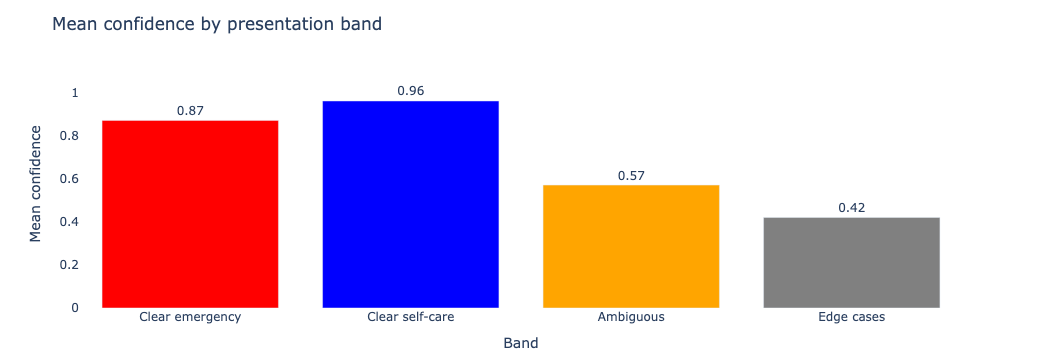


     band_label  mean_confidence  Emergency  Urgent Care  Routine  Self-Care
Clear emergency             0.87          4            1        0          0
Clear self-care             0.96          0            0        0          5
      Ambiguous             0.57          0            3        2          0
     Edge cases             0.42          3            1        0          1


In [10]:
band_order  = ["clear_emergency", "clear_self_care", "ambiguous", "edge"]
band_labels = {
    "clear_emergency": "Clear emergency",
    "clear_self_care": "Clear self-care",
    "ambiguous":       "Ambiguous",
    "edge":            "Edge cases",
}

band_summary = (
    results_df
    .groupby("band")
    .agg(
        mean_confidence=("confidence", "mean"),
        count          =("id",         "count"),
    )
    .reset_index()
)
band_summary["band"] = pd.Categorical(
    band_summary["band"], categories=band_order, ordered=True
)
band_summary = band_summary.sort_values("band")
band_summary["band_label"] = band_summary["band"].map(band_labels)
band_summary["mean_confidence"] = band_summary["mean_confidence"].round(2)

# Add pathway breakdown
for pathway in ["Emergency", "Urgent Care", "Routine", "Self-Care"]:
    band_summary[pathway] = band_summary["band"].apply(
        lambda b: (results_df[results_df["band"] == b]["pathway"] == pathway).sum()
    )

fig1 = go.Figure(go.Bar(
    x=band_summary["band_label"],
    y=band_summary["mean_confidence"],
    marker_color=["red", "blue", "orange", "grey"],
    text=[f"{v:.2f}" for v in band_summary["mean_confidence"]],
    textposition="outside",
))
fig1.update_layout(
    title="Mean confidence by presentation band",
    xaxis_title="Band",
    yaxis_title="Mean confidence",
    yaxis=dict(range=[0, 1.15]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig1.show()

print()
print(band_summary[["band_label", "mean_confidence", "Emergency",
                     "Urgent Care", "Routine", "Self-Care"]].to_string(index=False))

## 8. Pathway distribution

How did Jev distribute presentations across the four pathways?

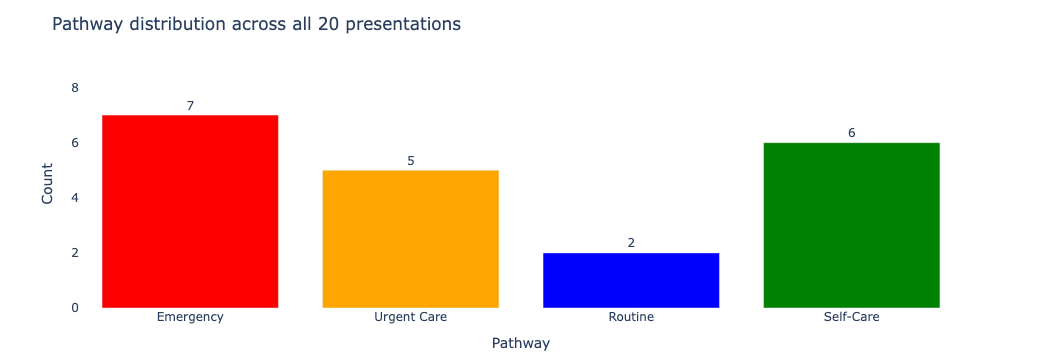


  Emergency   : 7 presentations, mean confidence 0.78
  Urgent Care : 5 presentations, mean confidence 0.51
  Routine     : 2 presentations, mean confidence 0.54
  Self-Care   : 6 presentations, mean confidence 0.83


In [11]:
pathway_order = ["Emergency", "Urgent Care", "Routine", "Self-Care"]
pathway_colors = {
    "Emergency":   "red",
    "Urgent Care": "orange",
    "Routine":     "blue",
    "Self-Care":   "green",
}

pathway_counts = (
    results_df["pathway"]
    .value_counts()
    .reindex(pathway_order, fill_value=0)
    .reset_index()
)
pathway_counts.columns = ["pathway", "count"]
pathway_counts["color"] = pathway_counts["pathway"].map(pathway_colors)

fig2 = go.Figure(go.Bar(
    x=pathway_counts["pathway"],
    y=pathway_counts["count"],
    marker_color=pathway_counts["color"],
    text=pathway_counts["count"],
    textposition="outside",
))
fig2.update_layout(
    title="Pathway distribution across all 20 presentations",
    xaxis_title="Pathway",
    yaxis_title="Count",
    yaxis=dict(range=[0, pathway_counts["count"].max() + 2]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig2.show()

print()
for pathway in pathway_order:
    subset = results_df[results_df["pathway"] == pathway]
    if len(subset) == 0:
        continue
    mean_conf = subset["confidence"].mean()
    print(f"  {pathway:12}: {len(subset)} presentations, "
          f"mean confidence {mean_conf:.2f}")

## 9. Confidence by pathway

Each presentation as a point, showing confidence and assigned pathway.

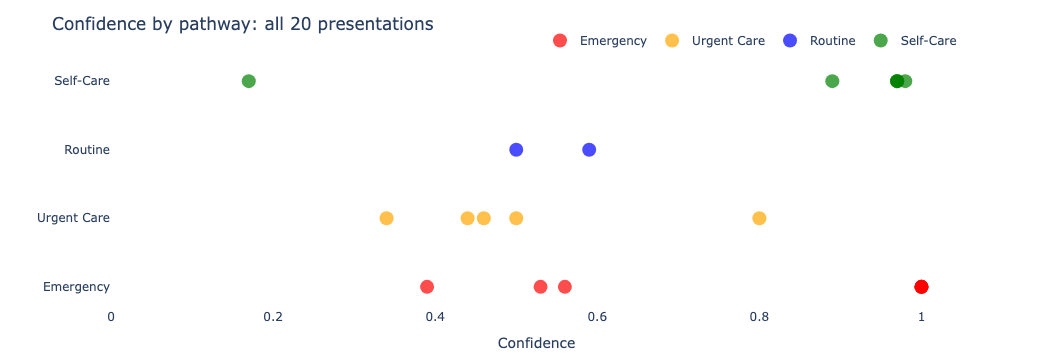

In [12]:
fig3 = go.Figure()

for pathway, color in pathway_colors.items():
    subset = results_df[results_df["pathway"] == pathway]
    if subset.empty:
        continue
    fig3.add_trace(go.Scatter(
        x=subset["confidence"],
        y=subset["pathway"],
        mode="markers",
        name=pathway,
        marker=dict(color=color, size=14, opacity=0.7),
        text=subset["id"] + " (age " + subset["age"].astype(str) + ")<br>"
             + subset["band"],
        hoverinfo="text+x",
    ))

fig3.update_layout(
    title="Confidence by pathway: all 20 presentations",
    xaxis_title="Confidence",
    xaxis=dict(range=[0, 1.05]),
    yaxis_title="",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig3.show()

## 10. Latency

In [13]:
print(f"Mean: {results_df['elapsed_ms'].mean():.0f}ms")
print(f"Min:  {results_df['elapsed_ms'].min():.0f}ms")
print(f"Max:  {results_df['elapsed_ms'].max():.0f}ms")

Mean: 214ms
Min:  190ms
Max:  255ms


## 11. Summary

One `Choice` call per presentation assigned each patient to a care pathway with a calibrated confidence score. Clear emergencies and clear self-care presentations produced high confidence. Ambiguous and edge case presentations produced lower confidence, which is the correct signal -- those are the presentations where clinical judgment matters most.

The conservative bias in the instructions ("when in doubt, assign the more urgent pathway") is deliberate. In medical triage, the cost of under-triaging a serious condition is far higher than the cost of over-triaging a minor one. A confidence-scored triage system makes that bias explicit and tunable.

In a real system, all decisions would be reviewed by a qualified clinician before any action is taken. The confidence score determines the priority of that review: high-confidence decisions can be processed quickly, low-confidence decisions need immediate human attention.

**Reminder: this notebook is for illustrative purposes only. Never use Jev or any AI system as a substitute for clinical judgment.**